In [2]:
import sys

print("Python version:", sys.version)
print("Python executable:", sys.executable)

Python version: 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)]
Python executable: d:\AI phishing project\venv\Scripts\python.exe


In [3]:
import pandas as pd
import os

DATA_PATH = os.path.join("..", "data", "data.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (20, 2)


,text,label
0,Your account has been suspended. Click here im...,1
1,Congratulations! You have won a prize. Click t...,1
2,Urgent action required. Confirm your bank acco...,1
3,Your password will expire today. Verify your a...,1
4,"Dear customer, your account has been selected ...",1


In [4]:
import os
import glob

dataset_files = glob.glob(
    os.path.join("..", "data", "dataset", "*.csv")
)

print("CSV files found:")
for file in dataset_files:
    print(file)

CSV files found:
..\data\dataset\Phishing_Email.csv


In [5]:
DATASET_PATH = dataset_files[0]

df_real = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully!")
print("Shape:", df_real.shape)
print("\nColumns:")
print(df_real.columns.tolist())

df_real.head()

Dataset loaded successfully!
Shape: (18650, 3)

Columns:
['Unnamed: 0', 'Email Text', 'Email Type']


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [6]:
# Remove the unnecessary index column
df = df_real[['Email Text', 'Email Type']].copy()

# Remove rows with missing email text or labels
df = df.dropna(subset=['Email Text', 'Email Type'])

# Remove duplicate emails
df = df.drop_duplicates(subset=['Email Text'])

# Clean the text
df['Email Text'] = df['Email Text'].astype(str).str.strip()

# Convert labels to numbers
# 0 = Safe Email
# 1 = Phishing Email
df['label'] = df['Email Type'].map({
    'Safe Email': 0,
    'Phishing Email': 1
})

# Remove any rows where the label could not be mapped
df = df.dropna(subset=['label'])

df['label'] = df['label'].astype(int)

print("Cleaning completed!")
print("Dataset shape:", df.shape)

print("\nClass distribution:")
print(df['Email Type'].value_counts())

df.head()

Cleaning completed!
Dataset shape: (17537, 3)

Class distribution:
Email Type
Safe Email        10979
Phishing Email     6558
Name: count, dtype: int64


,Email Text,Email Type,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,0
1,the other side of * galicismos * * galicismo *...,Safe Email,0
2,re : equistar deal tickets are you still avail...,Safe Email,0
3,Hello I am your hot lil horny toy.\n I am t...,Phishing Email,1
4,software at incredibly low prices ( 86 % lower...,Phishing Email,1


In [7]:
from sklearn.model_selection import train_test_split

X = df['Email Text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data split completed!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Data split completed!
Training samples: 14029
Testing samples: 3508

Training class distribution:
label
0    8783
1    5246
Name: count, dtype: int64

Testing class distribution:
label
0    2196
1    1312
Name: count, dtype: int64


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert email text into TF-IDF features
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF conversion completed!")
print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

TF-IDF conversion completed!
Training feature shape: (14029, 10000)
Testing feature shape: (3508, 10000)


In [9]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression classifier
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predict the test emails
y_pred = model.predict(X_test_tfidf)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MODEL EVALUATION RESULTS")
print("=" * 30)
print(f"Accuracy : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall   : {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1-Score : {f1:.4f} ({f1 * 100:.2f}%)")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Safe Email", "Phishing Email"]
))

MODEL EVALUATION RESULTS
Accuracy : 0.9803 (98.03%)
Precision: 0.9755 (97.55%)
Recall   : 0.9718 (97.18%)
F1-Score : 0.9737 (97.37%)

Classification Report:
                precision    recall  f1-score   support

    Safe Email       0.98      0.99      0.98      2196
Phishing Email       0.98      0.97      0.97      1312

      accuracy                           0.98      3508
     macro avg       0.98      0.98      0.98      3508
  weighted avg       0.98      0.98      0.98      3508



Confusion Matrix:
[[2164   32]
 [  37 1275]]


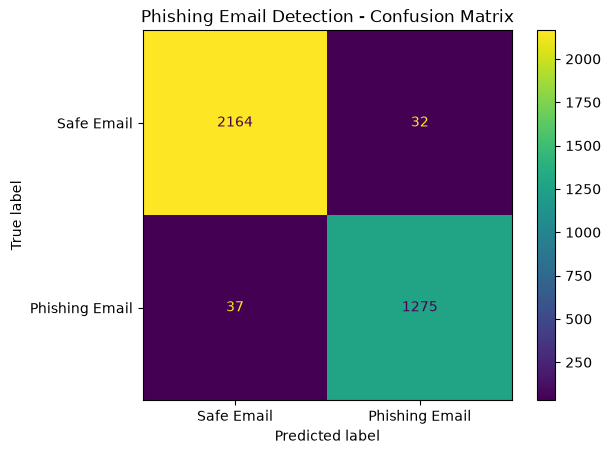

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Safe Email", "Phishing Email"]
)

disp.plot()
plt.title("Phishing Email Detection - Confusion Matrix")
plt.show()

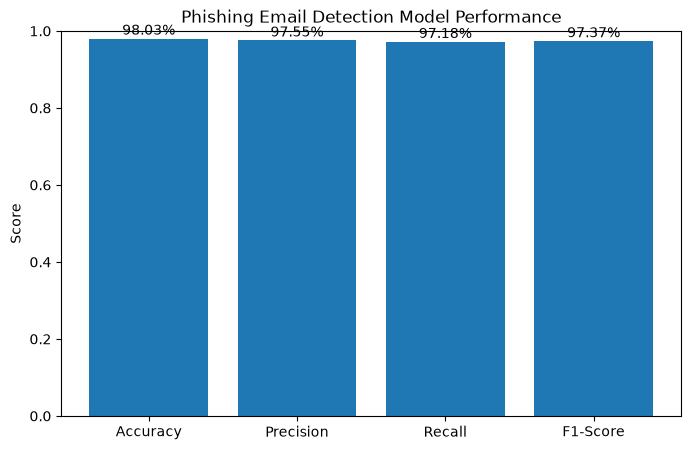

In [12]:
import matplotlib.pyplot as plt

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics.keys(), metrics.values())

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Phishing Email Detection Model Performance")

for bar, value in zip(bars, metrics.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value * 100:.2f}%",
        ha="center"
    )

plt.show()

In [13]:
import joblib
import os

# Make sure the model folder exists
os.makedirs("../model", exist_ok=True)

# Save the trained model
joblib.dump(model, "../model/phishing_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(vectorizer, "../model/tfidf_vectorizer.pkl")

print("Model saved successfully!")
print("Vectorizer saved successfully!")

print("\nSaved files:")
print("phishing_model.pkl")
print("tfidf_vectorizer.pkl")

Model saved successfully!
Vectorizer saved successfully!

Saved files:
phishing_model.pkl
tfidf_vectorizer.pkl


In [14]:
import joblib
# Load the saved model and vectorizer
saved_model = joblib.load("../model/phishing_model.pkl")
saved_vectorizer = joblib.load("../model/tfidf_vectorizer.pkl")

# Test emails
test_emails = [
    "Congratulations! You have won a prize. Click here to claim your reward.",
    "Hi, our meeting is scheduled for tomorrow at 10 AM. Please bring the project report."
]

# Convert test emails using the saved vectorizer
test_features = saved_vectorizer.transform(test_emails)

# Make predictions
predictions = saved_model.predict(test_features)

for email, prediction in zip(test_emails, predictions):
    result = "Phishing Email" if prediction == 1 else "Safe Email"
    print("Email:", email)
    print("Prediction:", result)
    print("-" * 60)

Email: Congratulations! You have won a prize. Click here to claim your reward.
Prediction: Phishing Email
------------------------------------------------------------
Email: Hi, our meeting is scheduled for tomorrow at 10 AM. Please bring the project report.
Prediction: Safe Email
------------------------------------------------------------
